In [52]:
import torch,torchvision
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import os
import random
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
RANDOM=42

root= ".data/"
atrtifacts_folder= "artifacts/"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256 if device.type == "cuda" else 64
print(device)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)), 
])
set_seed(RANDOM)
data_train = torchvision.datasets.EMNIST(root=root,train=True, split="balanced",download=True, transform= transform)
data_test= torchvision.datasets.EMNIST(root=root,train=0 , split="balanced",download=True,transform= transform)


BATCH_SIZE = 256 if device.type == "cuda" else 64


NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(data_train) * val_ratio)
train_size = len(data_train) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(data_train, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    data_test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)


x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [39]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256,256, 128),
        num_classes: int = 64,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [40]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    

def plot_history_compared(history: dict,history2: dict,exp1_name:str="",exp2_name:str="", title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axs = plt.subplots(2)
    
    
    axs[0].plot(epochs, history["val_loss"], label="val_loss "+exp1_name)
    axs[0].plot(epochs, history2["val_loss"], label="val_loss "+exp2_name)
    
    axs[0].set(ylabel=("loss"),xlabel=("epoch"))
    axs[0].set_title((title + " (loss)") if title else "loss")
    axs[0].legend()
    axs[0].grid(True)
    

    
    axs[1].plot(epochs, history["val_acc"], label="val_acc "+exp1_name)
    axs[1].plot(epochs, history2["val_acc"], label="val_acc "+exp2_name)
    axs[1].set(ylabel=("accuracy"),xlabel=("epoch"))
    axs[1].set_title((title + " (accuracy)") if title else "loss")
    axs[1].legend()
    axs[1].grid(True)
    fig.show()
    

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history
def clear():
    f = open(atrtifacts_folder+"runs.csv","w")
    f.write('')
    f.close()
    

def log_csv( id:str ,
            dataset:str,
            seed:int,
            model_summary:str,
            optimizer:str,
            lr,
            momentum,
            history,
             weight_deacay =0):

    df= pd.DataFrame({"experiment_id":[id], "dataset":[dataset],"seed":[seed],"model_summary":[model_summary],"optimizer":[optimizer],"lr":[lr],"momentum":[momentum],"weight_decay":[weight_deacay,],"epochs_trained":[len(history["train_loss"])],"best_val_accuracy":[history['val_acc'][-1]],"best_val_loss":[history['val_loss'][-1]] },columns=["experiment_id", "dataset","seed","model_summary","optimizer","lr","momentum","weight_decay","epochs_trained","best_val_accuracy","best_val_loss"],index=None)
    try:
        df.to_csv(atrtifacts_folder+"runs.csv",header=(True if os.path.getsize(atrtifacts_folder+"runs.csv")==0 else None),index=None, mode="a")
    except:
        df.to_csv(atrtifacts_folder+"runs.csv",header=True,index=None, mode="a")


In [41]:
clear()

## E1

epoch 01/20 | train loss=1.1384, acc=0.6599 | val loss=0.7386, acc=0.7618
epoch 02/20 | train loss=0.6359, acc=0.7906 | val loss=0.6274, acc=0.7968
epoch 03/20 | train loss=0.5432, acc=0.8156 | val loss=0.5800, acc=0.8099
epoch 04/20 | train loss=0.4903, acc=0.8305 | val loss=0.5301, acc=0.8313
epoch 05/20 | train loss=0.4544, acc=0.8398 | val loss=0.5114, acc=0.8292
epoch 06/20 | train loss=0.4263, acc=0.8483 | val loss=0.5029, acc=0.8361
epoch 07/20 | train loss=0.4010, acc=0.8559 | val loss=0.5193, acc=0.8296
epoch 08/20 | train loss=0.3828, acc=0.8594 | val loss=0.5029, acc=0.8332
epoch 09/20 | train loss=0.3677, acc=0.8642 | val loss=0.4927, acc=0.8420
epoch 10/20 | train loss=0.3517, acc=0.8678 | val loss=0.5194, acc=0.8354
epoch 11/20 | train loss=0.3427, acc=0.8712 | val loss=0.5221, acc=0.8375
epoch 12/20 | train loss=0.3338, acc=0.8737 | val loss=0.5143, acc=0.8385
epoch 13/20 | train loss=0.3213, acc=0.8775 | val loss=0.5382, acc=0.8336
epoch 14/20 | train loss=0.3107, acc=0

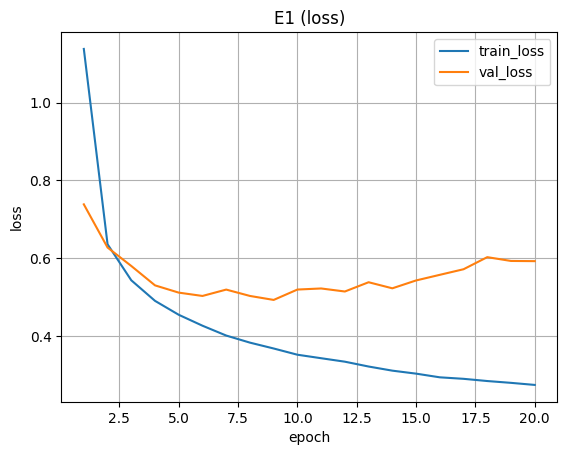

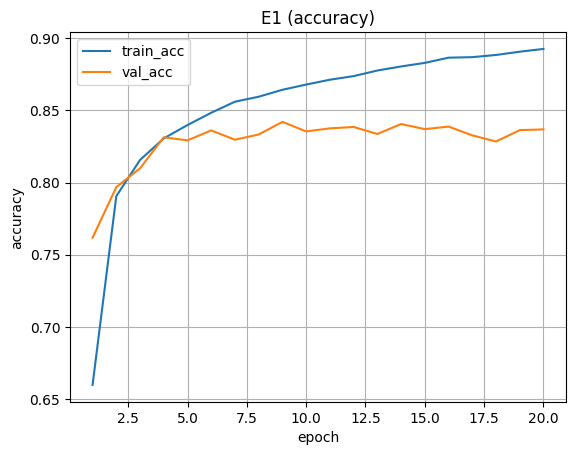

In [ ]:
set_seed(RANDOM)
model = MLP( dropout_p=0.0, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E1")
log_csv("E1","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False","Adam",1e-3,0,history)


## E2

epoch 01/20 | train loss=1.4181, acc=0.5782 | val loss=0.7968, acc=0.7496
epoch 02/20 | train loss=0.8971, acc=0.7174 | val loss=0.6618, acc=0.7844
epoch 03/20 | train loss=0.7951, acc=0.7455 | val loss=0.6016, acc=0.8061
epoch 04/20 | train loss=0.7427, acc=0.7600 | val loss=0.5809, acc=0.8082
epoch 05/20 | train loss=0.7085, acc=0.7691 | val loss=0.5479, acc=0.8187
epoch 06/20 | train loss=0.6906, acc=0.7744 | val loss=0.5311, acc=0.8219
epoch 07/20 | train loss=0.6696, acc=0.7795 | val loss=0.5342, acc=0.8211
epoch 08/20 | train loss=0.6579, acc=0.7812 | val loss=0.5157, acc=0.8266
epoch 09/20 | train loss=0.6426, acc=0.7869 | val loss=0.5111, acc=0.8282
epoch 10/20 | train loss=0.6362, acc=0.7883 | val loss=0.4978, acc=0.8317
epoch 11/20 | train loss=0.6313, acc=0.7899 | val loss=0.5057, acc=0.8290
epoch 12/20 | train loss=0.6181, acc=0.7917 | val loss=0.4908, acc=0.8304
epoch 13/20 | train loss=0.6136, acc=0.7937 | val loss=0.4967, acc=0.8324
epoch 14/20 | train loss=0.6093, acc=0

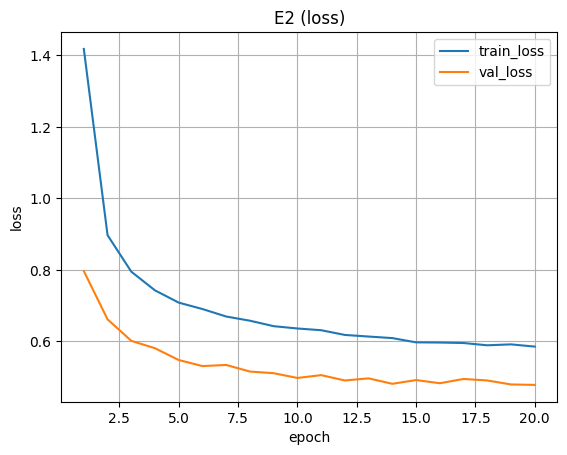

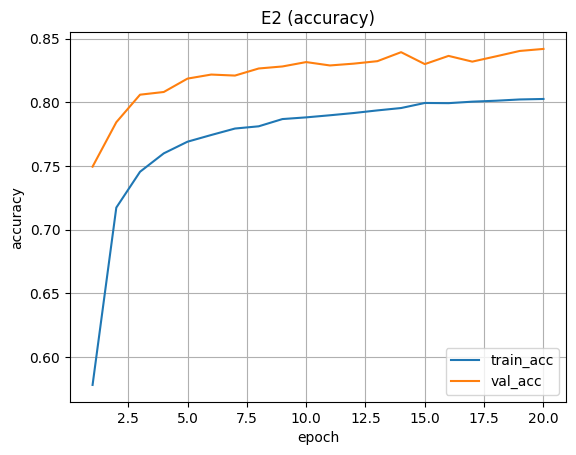

In [ ]:
set_seed(RANDOM)
model = MLP( dropout_p=0.2, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E2")
log_csv("E2","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.2, use_batchnorm=False","Adam",1e-3,0,history)

## E3

epoch 01/20 | train loss=0.8577, acc=0.7463 | val loss=0.5603, acc=0.8156
epoch 02/20 | train loss=0.5111, acc=0.8249 | val loss=0.4676, acc=0.8422
epoch 03/20 | train loss=0.4465, acc=0.8432 | val loss=0.4492, acc=0.8492
epoch 04/20 | train loss=0.4024, acc=0.8556 | val loss=0.4422, acc=0.8464
epoch 05/20 | train loss=0.3723, acc=0.8651 | val loss=0.4335, acc=0.8562
epoch 06/20 | train loss=0.3482, acc=0.8699 | val loss=0.4080, acc=0.8620
epoch 07/20 | train loss=0.3291, acc=0.8767 | val loss=0.4202, acc=0.8572
epoch 08/20 | train loss=0.3115, acc=0.8820 | val loss=0.4120, acc=0.8635
epoch 09/20 | train loss=0.2974, acc=0.8852 | val loss=0.4174, acc=0.8624
epoch 10/20 | train loss=0.2808, acc=0.8916 | val loss=0.4293, acc=0.8561
epoch 11/20 | train loss=0.2706, acc=0.8948 | val loss=0.4286, acc=0.8600
epoch 12/20 | train loss=0.2586, acc=0.8982 | val loss=0.4325, acc=0.8595
epoch 13/20 | train loss=0.2511, acc=0.8996 | val loss=0.4323, acc=0.8620
epoch 14/20 | train loss=0.2422, acc=0

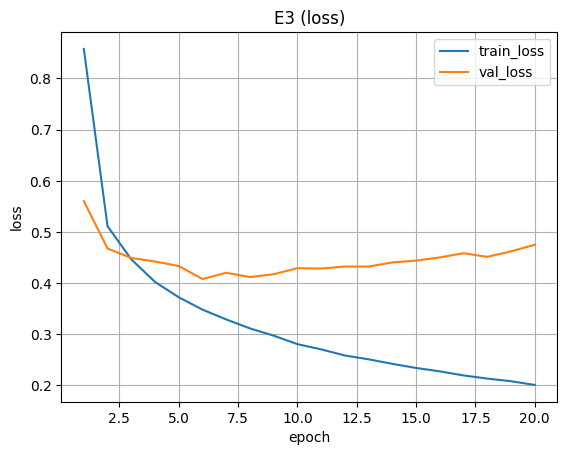

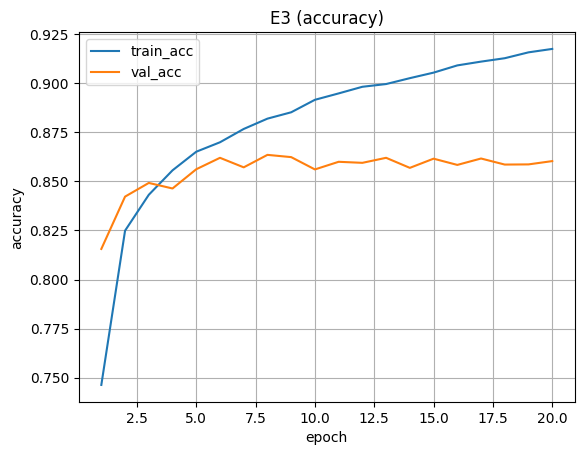

In [ ]:
set_seed(RANDOM)
model = MLP( dropout_p=0.0, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E3")
log_csv("E3","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

In [ ]:
set_seed(RANDOM)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Baseline test: loss=0.5196, acc=0.8512


## E4

In [46]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.8896, acc=0.7429 | val loss=0.5672, acc=0.8158
epoch 02/20 | train loss=0.5251, acc=0.8242 | val loss=0.5035, acc=0.8317
epoch 03/20 | train loss=0.4576, acc=0.8420 | val loss=0.4688, acc=0.8462
epoch 04/20 | train loss=0.4201, acc=0.8524 | val loss=0.4572, acc=0.8447
epoch 05/20 | train loss=0.3878, acc=0.8614 | val loss=0.4480, acc=0.8483
epoch 06/20 | train loss=0.3649, acc=0.8675 | val loss=0.4474, acc=0.8515
epoch 07/20 | train loss=0.3439, acc=0.8734 | val loss=0.4513, acc=0.8524
epoch 08/20 | train loss=0.3275, acc=0.8779 | val loss=0.4513, acc=0.8513
epoch 09/20 | train loss=0.3129, acc=0.8833 | val loss=0.4442, acc=0.8528
epoch 10/20 | train loss=0.3004, acc=0.8862 | val loss=0.4516, acc=0.8523
epoch 11/20 | train loss=0.2897, acc=0.8889 | val loss=0.4466, acc=0.8556
epoch 12/20 | train loss=0.2771, acc=0.8928 | val loss=0.4553, acc=0.8563
epoch 13/20 | train loss=0.2694, acc=0.8950 | val loss=0.4677, acc=0.8532
epoch 14/20 | train loss=0.2607, acc=0

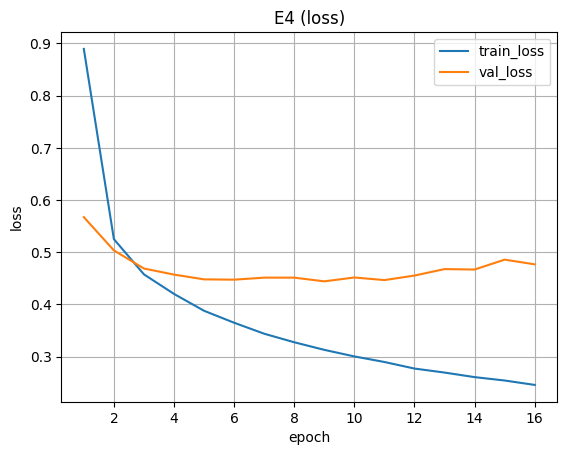

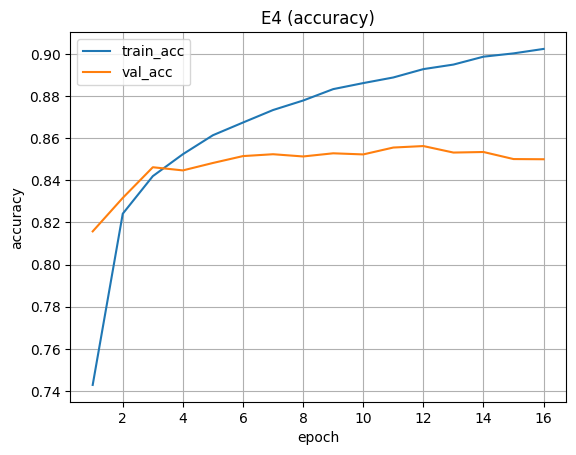

In [ ]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=es
)

plot_history(history_baseline, title="E4")
log_csv("E4","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)
torch.save(model.state_dict(),atrtifacts_folder+"best_model.pt")

## O1

epoch 01/7 | train loss=1.1838, acc=0.6463 | val loss=0.9618, acc=0.7076
epoch 02/7 | train loss=0.8732, acc=0.7259 | val loss=0.7392, acc=0.7667
epoch 03/7 | train loss=0.8033, acc=0.7454 | val loss=0.7151, acc=0.7752
epoch 04/7 | train loss=0.7623, acc=0.7579 | val loss=0.7437, acc=0.7654
epoch 05/7 | train loss=0.7388, acc=0.7661 | val loss=0.7130, acc=0.7708
epoch 06/7 | train loss=0.7061, acc=0.7726 | val loss=0.6475, acc=0.7928
epoch 07/7 | train loss=0.6841, acc=0.7791 | val loss=0.6641, acc=0.7892


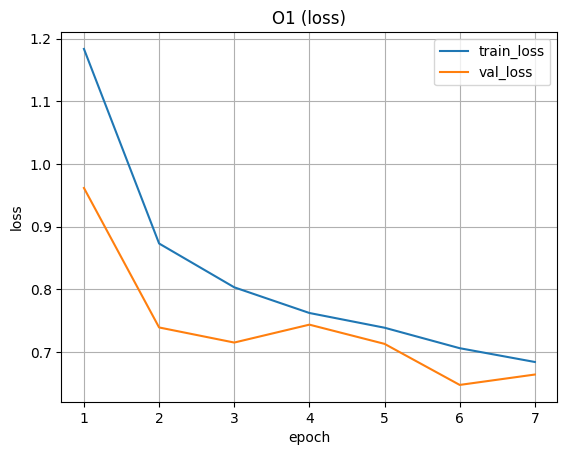

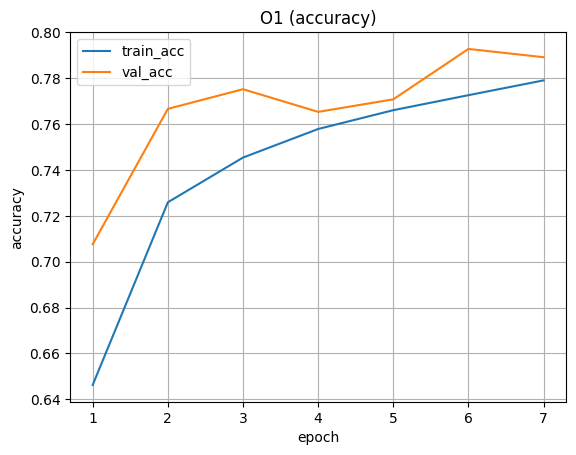

In [ ]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)
o1_history= history_baseline.copy()
plot_history(history_baseline, title="O1")
log_csv("O1","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

## O2

epoch 01/7 | train loss=4.2366, acc=0.0116 | val loss=4.2381, acc=0.0132
epoch 02/7 | train loss=4.2372, acc=0.0117 | val loss=4.2400, acc=0.0124
epoch 03/7 | train loss=4.2368, acc=0.0118 | val loss=4.2403, acc=0.0123
epoch 04/7 | train loss=4.2368, acc=0.0122 | val loss=4.2413, acc=0.0120
epoch 05/7 | train loss=4.2374, acc=0.0115 | val loss=4.2377, acc=0.0118
epoch 06/7 | train loss=4.2371, acc=0.0122 | val loss=4.2373, acc=0.0124
epoch 07/7 | train loss=4.2371, acc=0.0117 | val loss=4.2386, acc=0.0124


C:\Users\study\AppData\Local\Temp\ipykernel_28560\3885603788.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


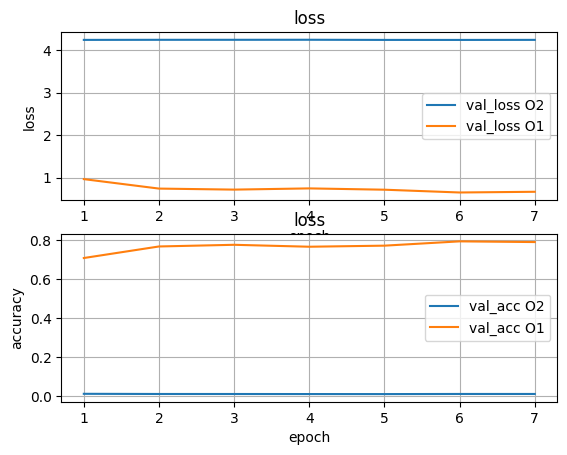

In [49]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-11)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)

plot_history_compared(history_baseline,o1_history,"O2","O1")
log_csv("O2","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

## O3

epoch 01/7 | train loss=2.4252, acc=0.4988 | val loss=1.5468, acc=0.6546
epoch 02/7 | train loss=1.2768, acc=0.6909 | val loss=1.0333, acc=0.7357
epoch 03/7 | train loss=0.9470, acc=0.7460 | val loss=0.8301, acc=0.7751
epoch 04/7 | train loss=0.7882, acc=0.7785 | val loss=0.7137, acc=0.7974
epoch 05/7 | train loss=0.6921, acc=0.7984 | val loss=0.6479, acc=0.8120
epoch 06/7 | train loss=0.6295, acc=0.8122 | val loss=0.6052, acc=0.8220
epoch 07/7 | train loss=0.5848, acc=0.8221 | val loss=0.5759, acc=0.8250


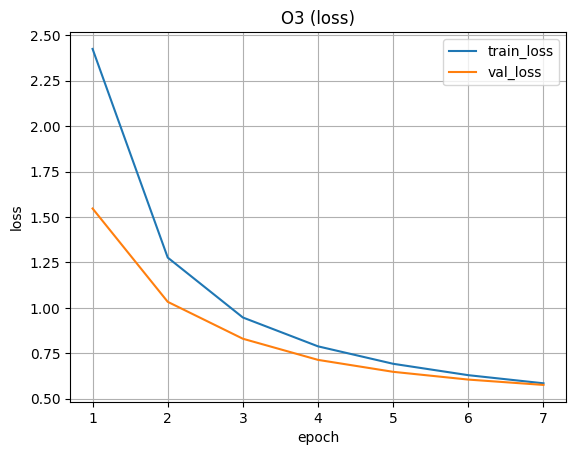

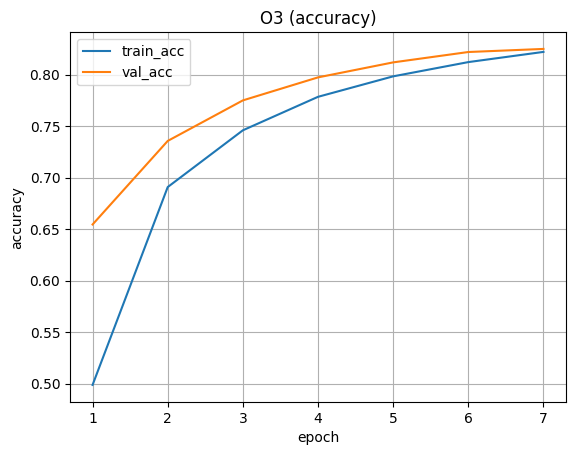

In [53]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3,momentum=0.8)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)

plot_history(history_baseline, title="O3")
log_csv("O3","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)